# 05 — Hotspots EDA

Explores the INPE fire hotspot dataset to understand fire seasonality,
intensity patterns, and city-level differences across 2022–2025.

All analysis reads from `data/processed/hotspots_clean.parquet`.
No data is modified here.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path

ROOT = Path().resolve()
PROCESSED = ROOT / "data" / "processed"

df = pd.read_parquet(PROCESSED / "hotspots_clean.parquet")

# City colors — consistent with notebook 03
city_colors = {
    "Manaus": "#e05c2a",
    "Brasília": "#e0a82a",
    "Belo Horizonte": "#4a9e6b",
    "São Paulo": "#4a7ab5",
    "Porto Alegre": "#7b5ea7",
}

print(f"Shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"Cities: {sorted(df['city'].unique())}")

Shape: (3864, 11)
Date range: 2022-01-01 00:00:00+00:00 → 2025-12-31 00:00:00+00:00
Cities: ['Belo Horizonte', 'Brasília', 'Manaus', 'Porto Alegre', 'São Paulo']


In [4]:
# Monthly aggregation for time series analysis
# Sum hotspot_count and frp_total — both are cumulative measures
# Mean frp_mean and risk_fire_mean — both are averages by nature

df["year_month"] = df["timestamp"].dt.to_period("M")
df["month"] = df["timestamp"].dt.month

df_monthly = (
    df.groupby(["city", "year_month"])
    .agg(
        hotspot_count=("hotspot_count", "sum"),
        frp_total=("frp_total", "sum"),
        frp_mean=("frp_mean", "mean"),
        risk_fire_mean=("risk_fire_mean", "mean"),
        year=("year", "first"),
    )
    .reset_index()
)

df_monthly["date"] = df_monthly["year_month"].dt.to_timestamp()

print(f"Monthly rows: {len(df_monthly)}")
print(df_monthly.head(3).to_string(index=False))

Monthly rows: 229
          city year_month  hotspot_count  frp_total  frp_mean  risk_fire_mean  year       date
Belo Horizonte    2022-01            110     1975.8 17.543821        0.107761  2022 2022-01-01
Belo Horizonte    2022-02             66     1179.5 18.228617        0.084778  2022 2022-02-01
Belo Horizonte    2022-03            190     3942.5 23.570069        0.447998  2022 2022-03-01


C:\Users\pbbab\AppData\Local\Temp\ipykernel_27384\539732635.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["year_month"] = df["timestamp"].dt.to_period("M")


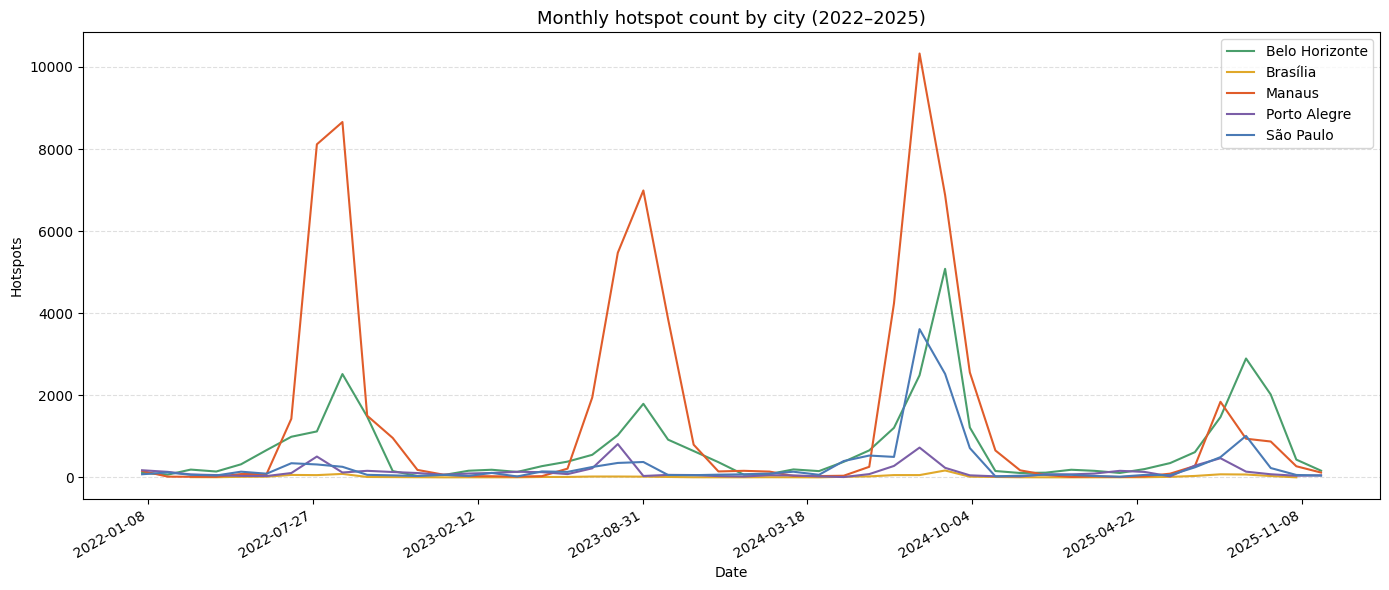

In [5]:
# Question: How does monthly hotspot count evolve over time across cities?
# Are fire peaks seasonal? Does 2024 stand out? Which city dominates?

fig, ax = plt.subplots(figsize=(14, 6))

for city, group in df_monthly.groupby("city"):
    ax.plot(
        group["date"],
        group["hotspot_count"],
        label=city,
        color=city_colors[city],
        linewidth=1.5,
    )

ax.set_title("Monthly hotspot count by city (2022–2025)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Hotspots")
ax.legend(loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Format x-axis to show year labels cleanly
ax.xaxis.set_major_locator(ticker.MaxNLocator(10))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

## Finding 1 — Fire hotspots show strong dry season seasonality with 2024 as an extreme year

- All cities show near-identical seasonal pattern: peak July–September, near-zero January–March — dry season is the dominant driver of fire activity
- Manaus (Amazonas state) dominates raw counts by an order of magnitude due to state size — peak of ~10,300 hotspots in September 2024
- 2024 is anomalous across multiple cities simultaneously — BH and SP both spike dramatically compared to prior years, consistent with El Niño-driven national drought
- São Paulo reaches ~3,500 hotspots in September 2024 vs near-zero in 2022–2023 — a striking departure from baseline
- 2025 shows sharp Manaus recovery — potentially reflecting government enforcement (Programa Queimadas Zero) but confounded with post-El Niño weather recovery — requires weather-controlled analysis to separate
- Brasília (DF) barely registers — DF's small area makes raw hotspot count a poor proxy for regional fire pressure, reinforcing the case for including Goiás in the Brasília fire indicator

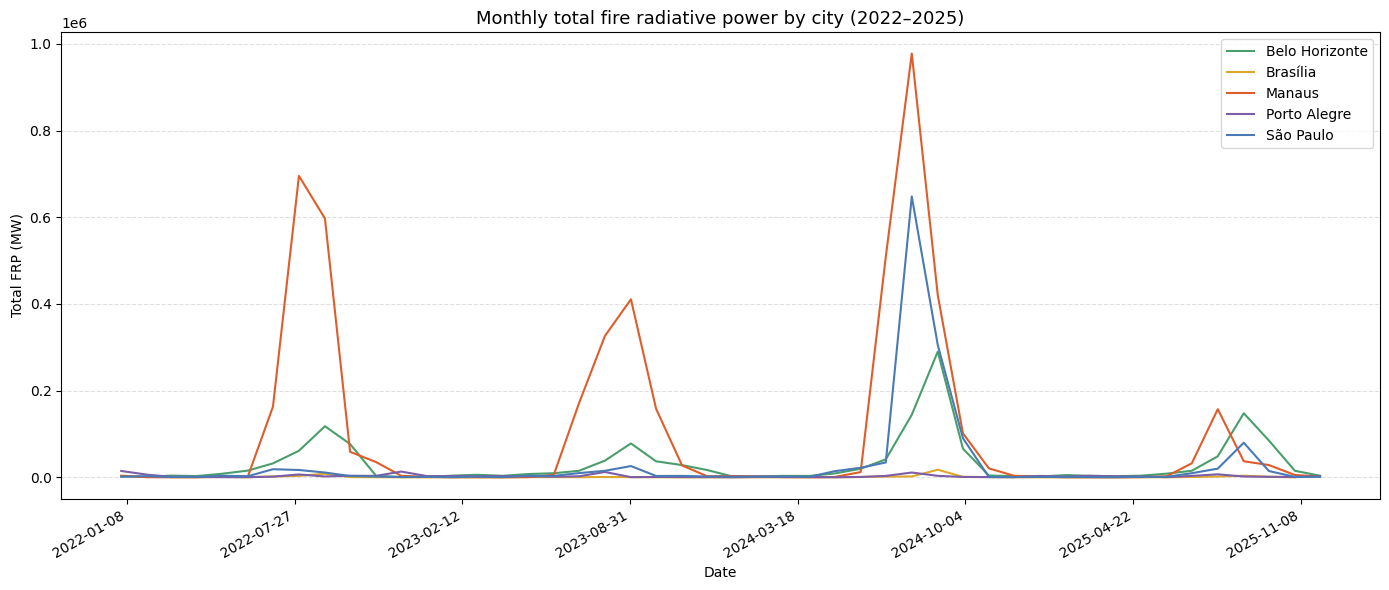

In [6]:
# ── FRP intensity over time ───────────────────────────────────────────────────
# Question: Does 2024 stand out on fire INTENSITY as well as count?
# FRP (Fire Radiative Power) measures energy released by fires in megawatts
# A high FRP means fewer but more intense fires — better proxy for smoke production
# than raw count alone

fig, ax = plt.subplots(figsize=(14, 6))

for city, group in df_monthly.groupby("city"):
    ax.plot(
        group["date"],
        group["frp_total"],      # total energy released by all fires that month
        label=city,
        color=city_colors[city],
        linewidth=1.5,
    )

ax.set_title("Monthly total fire radiative power by city (2022–2025)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Total FRP (MW)")
ax.legend(loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.xaxis.set_major_locator(ticker.MaxNLocator(10))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

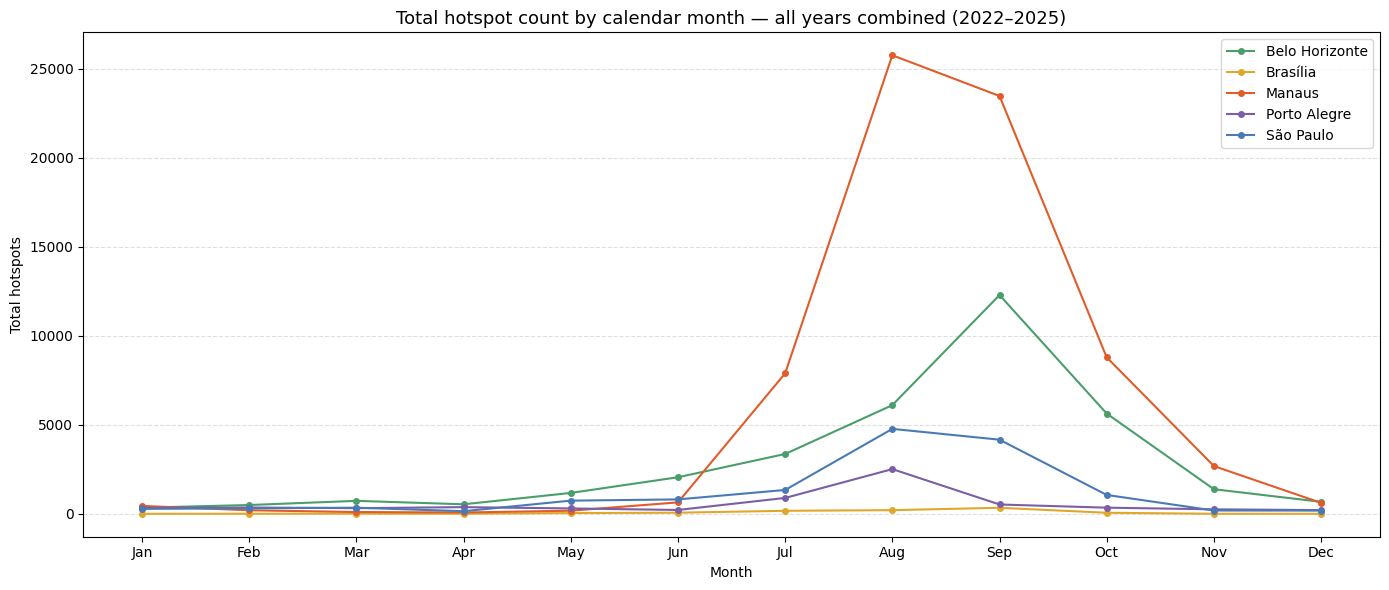

In [7]:
# ── Typical fire season ───────────────────────────────────────────────────────
# Question: Which months are consistently the peak fire months across all years?
# We sum hotspot counts by calendar month across all 4 years combined
# This gives us the "typical fire year" baseline — equivalent to the
# seasonal temperature chart in notebook 03

df["month"] = df["timestamp"].dt.month

# Sum (not mean) because we want total fire pressure per month across all years
df_seasonal = (
    df.groupby(["city", "month"])["hotspot_count"]
    .sum()
    .reset_index()
)

month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(14, 6))

for city, group in df_seasonal.groupby("city"):
    ax.plot(
        group["month"],
        group["hotspot_count"],
        label=city,
        color=city_colors[city],
        linewidth=1.5,
        marker="o",       # dot at each month makes the peak clearer
        markersize=4,
    )

ax.set_title("Total hotspot count by calendar month — all years combined (2022–2025)", fontsize=13)
ax.set_xlabel("Month")
ax.set_ylabel("Total hotspots")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.legend(loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

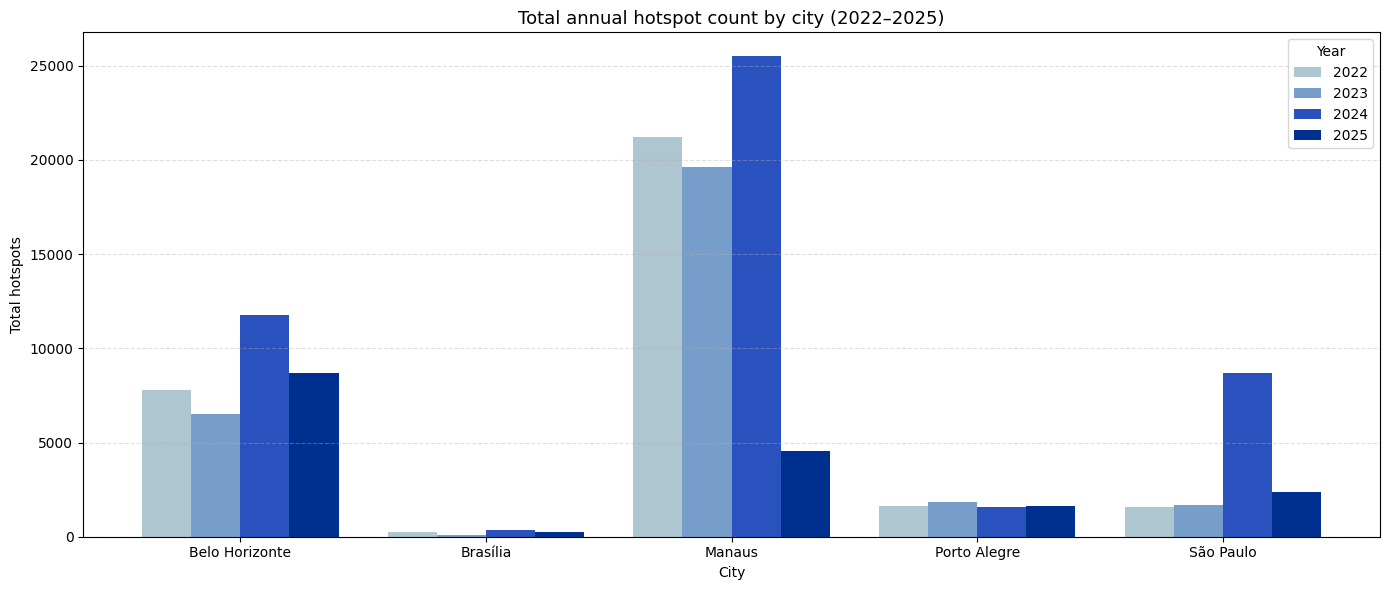

In [8]:
# ── Year-over-year comparison ─────────────────────────────────────────────────
# Question: Which year had the most fire activity per city?
# Grouped bar chart — one cluster per city, one bar per year
# Colors go light to dark blue to represent time progression 2022→2025

df_yearly = (
    df.groupby(["city", "year"])["hotspot_count"]
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))

cities = sorted(df["city"].unique())
x = range(len(cities))
width = 0.2                                    # width of each individual bar
years = [2022, 2023, 2024, 2025]
year_colors = ["#aec6cf", "#779ecb", "#2a52be", "#00308f"]  # light to dark blue

for i, year in enumerate(years):
    # Get hotspot total for each city for this year
    vals = [
        df_yearly[
            (df_yearly["city"] == c) & (df_yearly["year"] == year)
        ]["hotspot_count"].sum()
        for c in cities
    ]
    ax.bar(
        [xi + i * width for xi in x],  # offset each year's bars within the cluster
        vals,
        width=width,
        label=str(year),
        color=year_colors[i],
    )

ax.set_title("Total annual hotspot count by city (2022–2025)", fontsize=13)
ax.set_xlabel("City")
ax.set_ylabel("Total hotspots")

# Center x-axis labels under each cluster of 4 bars
ax.set_xticks([xi + 1.5 * width for xi in x])
ax.set_xticklabels(cities)
ax.legend(title="Year")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

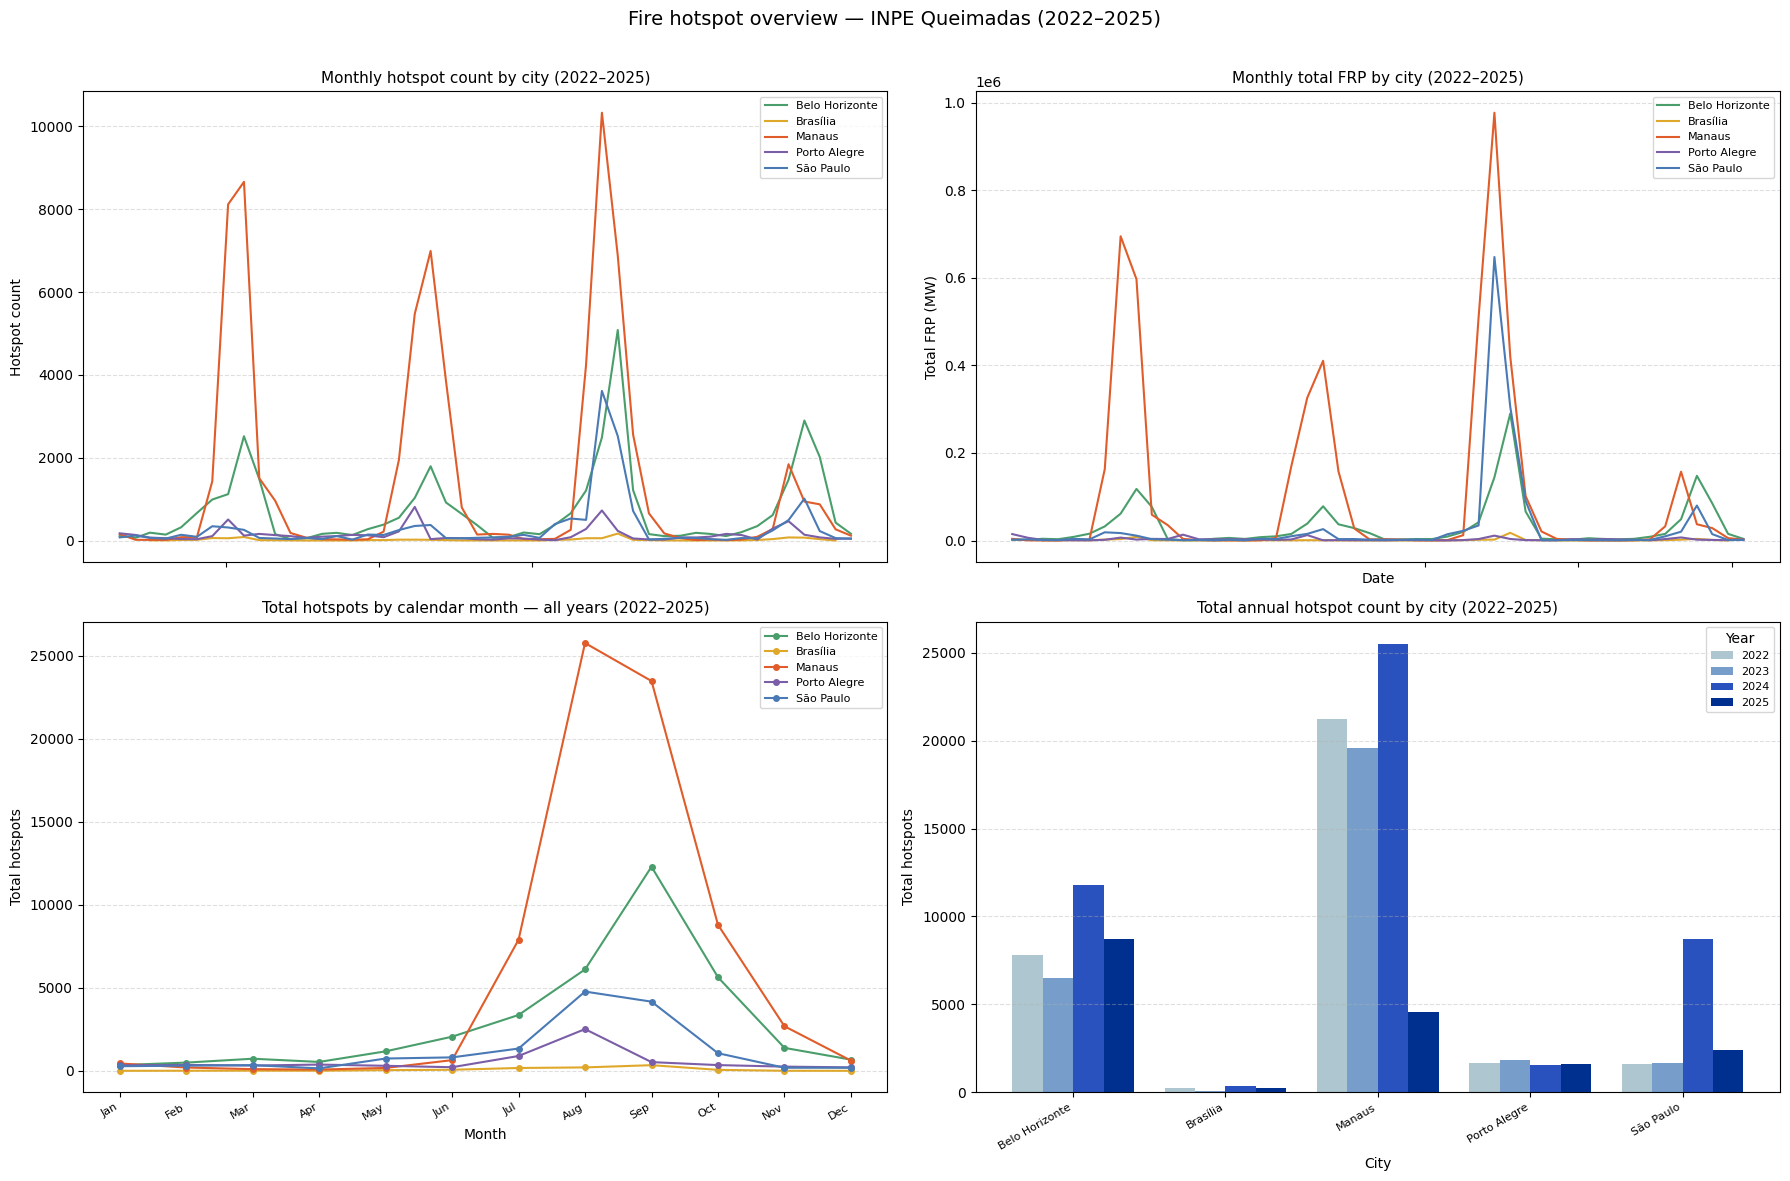

In [9]:
# ── All hotspot EDA charts in one figure ─────────────────────────────────────
# Four panels arranged in a 2×2 grid for a complete overview of the dataset
# Top row: time series (count and intensity)
# Bottom row: seasonal pattern and year-over-year comparison

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))

# ── Panel 1: Monthly hotspot count over time ──────────────────────────────────
ax1 = axes[0, 0]
for city, group in df_monthly.groupby("city"):
    ax1.plot(
        group["date"],
        group["hotspot_count"],
        label=city,
        color=city_colors[city],
        linewidth=1.5,
    )
ax1.set_title("Monthly hotspot count by city (2022–2025)", fontsize=11)
ax1.set_xlabel("Date")
ax1.set_ylabel("Hotspot count")
ax1.legend(loc="upper right", fontsize=8)
ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax1.xaxis.set_major_locator(ticker.MaxNLocator(6))
fig.autofmt_xdate()

# ── Panel 2: Monthly total FRP over time ──────────────────────────────────────
# FRP (Fire Radiative Power) measures fire intensity in megawatts
# Complements count — checks whether 2024 anomaly is count-driven or intensity-driven
ax2 = axes[0, 1]
for city, group in df_monthly.groupby("city"):
    ax2.plot(
        group["date"],
        group["frp_total"],
        label=city,
        color=city_colors[city],
        linewidth=1.5,
    )
ax2.set_title("Monthly total FRP by city (2022–2025)", fontsize=11)
ax2.set_xlabel("Date")
ax2.set_ylabel("Total FRP (MW)")
ax2.legend(loc="upper right", fontsize=8)
ax2.grid(axis="y", linestyle="--", alpha=0.4)
ax2.xaxis.set_major_locator(ticker.MaxNLocator(6))

# ── Panel 3: Typical fire season ─────────────────────────────────────────────
# Sums all hotspots by calendar month across all 4 years
# Shows the underlying seasonal structure stripped of year-to-year noise
ax3 = axes[1, 0]
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

df_seasonal = (
    df.groupby(["city", "month"])["hotspot_count"]
    .sum()
    .reset_index()
)

for city, group in df_seasonal.groupby("city"):
    ax3.plot(
        group["month"],
        group["hotspot_count"],
        label=city,
        color=city_colors[city],
        linewidth=1.5,
        marker="o",     # dot at each month makes the peak month clearer
        markersize=4,
    )
ax3.set_title("Total hotspots by calendar month — all years (2022–2025)", fontsize=11)
ax3.set_xlabel("Month")
ax3.set_ylabel("Total hotspots")
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(month_names, fontsize=8)
ax3.legend(loc="upper right", fontsize=8)
ax3.grid(axis="y", linestyle="--", alpha=0.4)

# ── Panel 4: Year-over-year comparison ───────────────────────────────────────
# Grouped bar chart — one cluster per city, one bar per year
# Light to dark blue encodes time progression 2022→2025
ax4 = axes[1, 1]
cities = sorted(df["city"].unique())
x = range(len(cities))
width = 0.2
years = [2022, 2023, 2024, 2025]
year_colors = ["#aec6cf", "#779ecb", "#2a52be", "#00308f"]

df_yearly = (
    df.groupby(["city", "year"])["hotspot_count"]
    .sum()
    .reset_index()
)

for i, year in enumerate(years):
    vals = [
        df_yearly[
            (df_yearly["city"] == c) & (df_yearly["year"] == year)
        ]["hotspot_count"].sum()
        for c in cities
    ]
    ax4.bar(
        [xi + i * width for xi in x],  # offset bars within each city cluster
        vals,
        width=width,
        label=str(year),
        color=year_colors[i],
    )

ax4.set_title("Total annual hotspot count by city (2022–2025)", fontsize=11)
ax4.set_xlabel("City")
ax4.set_ylabel("Total hotspots")
ax4.set_xticks([xi + 1.5 * width for xi in x])
ax4.set_xticklabels(cities, fontsize=8)
ax4.legend(title="Year", fontsize=8)
ax4.grid(axis="y", linestyle="--", alpha=0.4)

fig.suptitle("Fire hotspot overview — INPE Queimadas (2022–2025)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Finding 2 — Fire season is tightly bounded June–October across all cities

- All cities show near-zero fire activity January–May and November–December
- Peak months are August–September universally — aligning precisely with minimum
  humidity months identified in the weather EDA
- The tight weather-fire alignment confirms dry season conditions are the
  primary driver of fire activity across all climate regimes

## Finding 3 — 2024 is anomalous in both count and intensity

- São Paulo: ~1,500 annual hotspots in 2022–2023 → ~8,700 in 2024 (5x increase)
  with FRP matching Amazonas-scale intensity — exceptional for a non-fire-prone state
- Manaus: highest count and FRP of the entire 4-year period in 2024
- Both count and intensity metrics confirm 2024 as a genuine extreme year,
  not just a counting artifact

## Finding 4 — BH shows high count but low intensity (agricultural burning signature)

- Many small fires throughout the year rather than large intense events
- Consistent with sugarcane harvesting and agricultural burning in MG's interior
- Contrasts with Manaus (large, intense forest fires) and SP 2024 (anomalous intensity)

## Finding 5 — Manaus 2025 returns toward pre-2024 baseline

- 2025 hotspot count and FRP resemble 2023 more than 2024
- Consistent with both post-El Niño weather recovery and government enforcement
- Cannot separate policy effect from weather effect without controlling for
  drought conditions — flagged for integration analysis

## Limitation — state-level fire data as a climate stress indicator

- State boundaries are too large to establish direct causal links between
  specific fires and urban air quality
- Fire data will be used as a regional climate stress index in integration analysis
- Strong correlations between fire peaks and weather anomalies (humidity, temperature)
  are the primary analytical value of this dataset

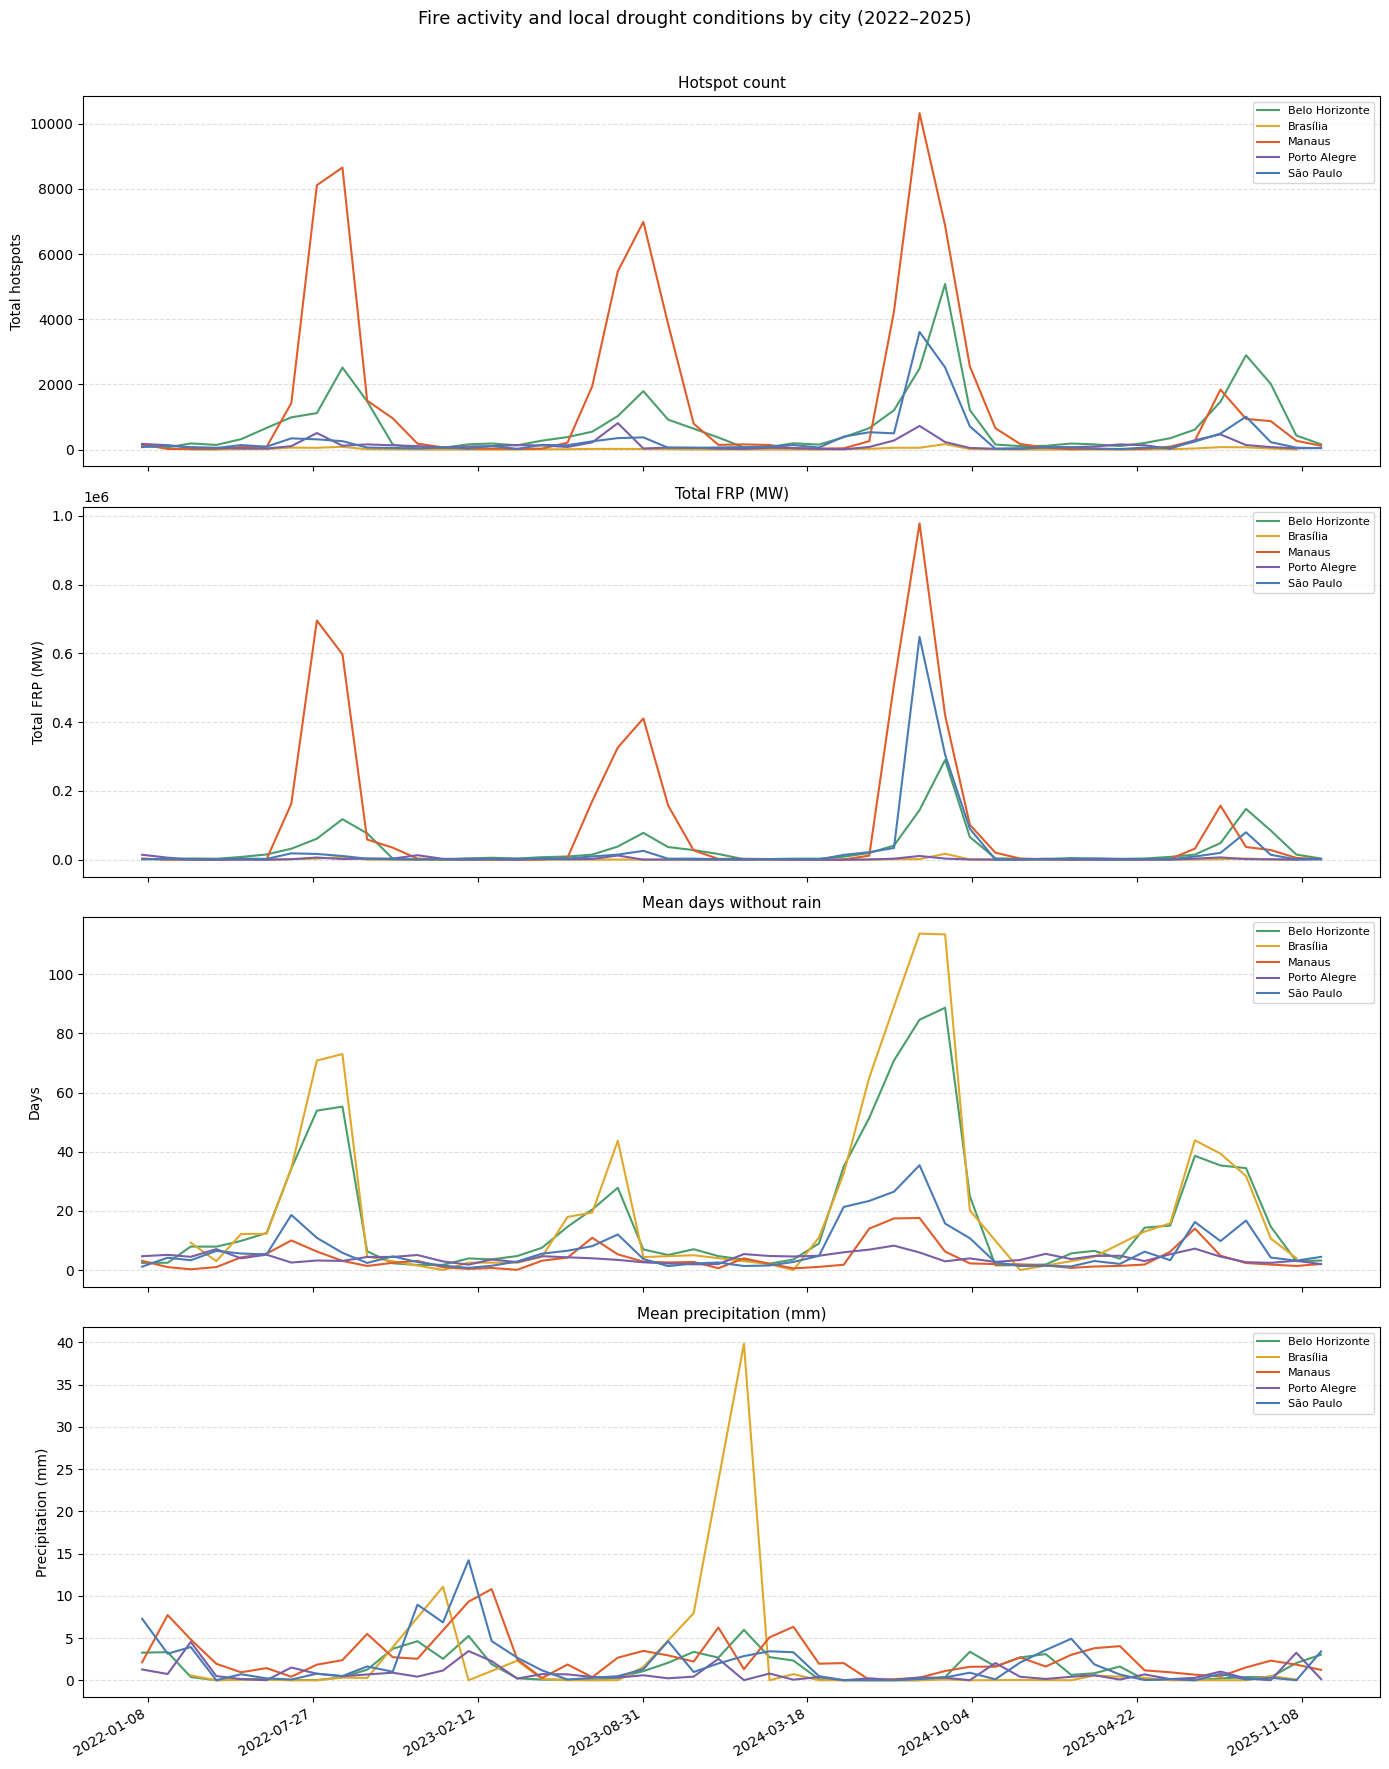

In [11]:
# ── Fire conditions overview — hotspots, FRP, drought and precipitation ───────
# This chart combines fire activity metrics with the local weather conditions
# recorded at each hotspot detection point
# Days without rain and precipitation come from the INPE dataset itself —
# they reflect conditions at the fire location, not city-level weather station data

# We need city-level monthly aggregations including the drought/precip columns
df_conditions = (
    df.groupby(["city", "year_month"])
    .agg(
        hotspot_count=("hotspot_count", "sum"),
        frp_total=("frp_total", "sum"),
        days_no_rain=("days_no_rain_mean", "mean"),   # mean across all hotspot days
        precip=("precip_mean", "mean"),               # mean precipitation at hotspots
    )
    .reset_index()
)
df_conditions["date"] = df_conditions["year_month"].dt.to_timestamp()

# One row of subplots per variable, one line per city
# 4 variables × shared x-axis makes vertical comparison easy
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 18), sharex=True)

variables = [
    ("hotspot_count", "Hotspot count",        "Total hotspots"),
    ("frp_total",     "Total FRP (MW)",        "Total FRP (MW)"),
    ("days_no_rain",  "Mean days without rain","Days"),
    ("precip",        "Mean precipitation (mm)","Precipitation (mm)"),
]

for ax, (col, title, ylabel) in zip(axes, variables):
    for city, group in df_conditions.groupby("city"):
        ax.plot(
            group["date"],
            group[col],
            label=city,
            color=city_colors[city],
            linewidth=1.5,
        )
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.legend(loc="upper right", fontsize=8)

# Only bottom panel needs x-axis labels since sharex=True links all panels
axes[-1].xaxis.set_major_locator(ticker.MaxNLocator(10))
fig.autofmt_xdate()

fig.suptitle("Fire activity and local drought conditions by city (2022–2025)", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [12]:
# Rebuild df_monthly including drought variables
# days_no_rain_mean and precip_mean are measured at hotspot locations
# making them locally relevant drought indicators

df_monthly = (
    df.groupby(["city", "year_month"])
    .agg(
        hotspot_count=("hotspot_count", "sum"),
        frp_total=("frp_total", "sum"),
        frp_mean=("frp_mean", "mean"),
        risk_fire_mean=("risk_fire_mean", "mean"),
        days_no_rain_mean=("days_no_rain_mean", "mean"),
        precip_mean=("precip_mean", "mean"),
        year=("year", "first"),
    )
    .reset_index()
)

df_monthly["date"] = df_monthly["year_month"].dt.to_timestamp()

print(f"Columns: {df_monthly.columns.tolist()}")
print(f"Shape: {df_monthly.shape}")

Columns: ['city', 'year_month', 'hotspot_count', 'frp_total', 'frp_mean', 'risk_fire_mean', 'days_no_rain_mean', 'precip_mean', 'year', 'date']
Shape: (229, 10)


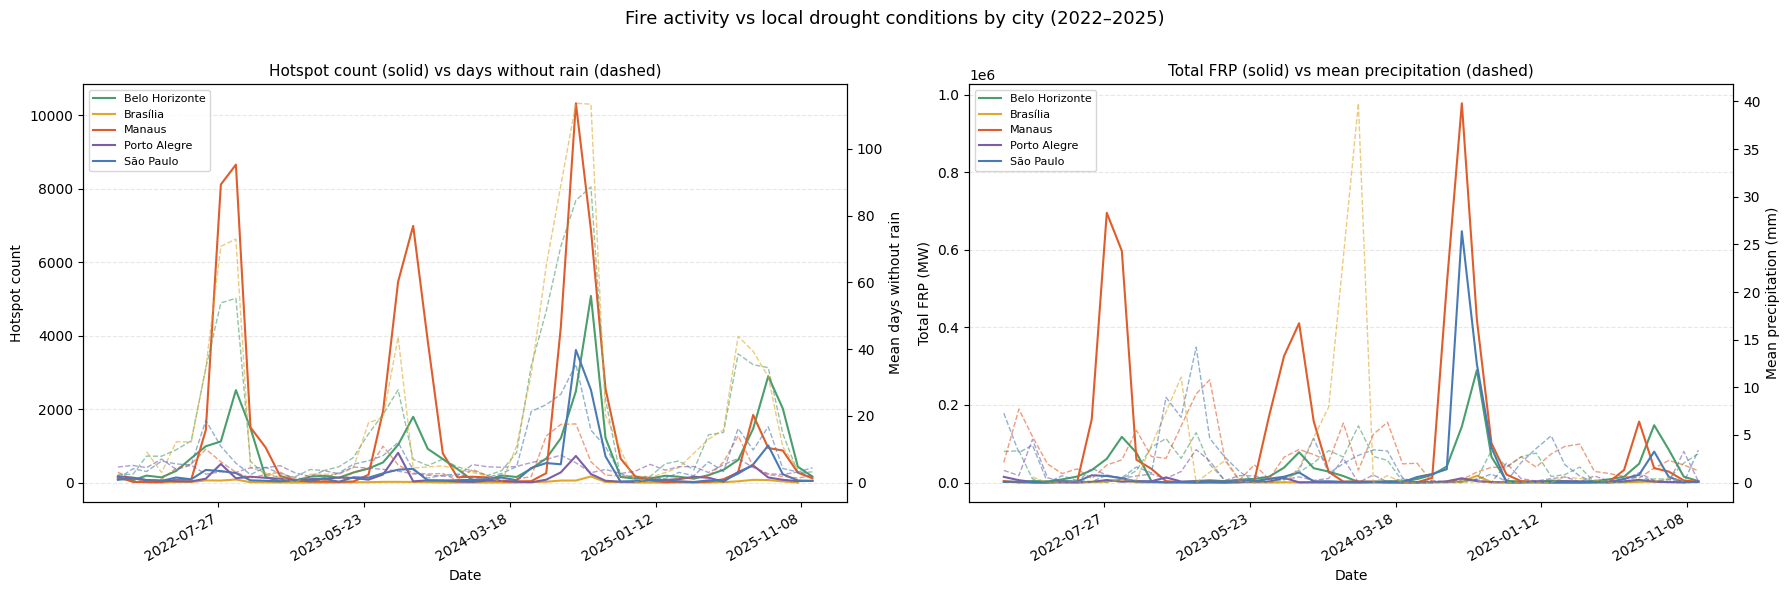

In [13]:
# ── Hotspot count vs days without rain / FRP vs precipitation ─────────────────
# Left panel: hotspot count + days without rain
#   — tests whether drought duration drives ignition frequency
# Right panel: total FRP + mean precipitation
#   — tests whether rainfall suppresses fire intensity
# Both panels use twinx() so each variable keeps its own y-axis scale
# Solid lines = fire variables (left axis), dashed = drought variables (right axis)

fig, (ax_left, ax_right) = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# ── Left panel: hotspot count vs days without rain ────────────────────────────
ax_left2 = ax_left.twinx()

for city, group in df_monthly.groupby("city"):
    # Hotspot count — solid line on left axis
    ax_left.plot(
        group["date"],
        group["hotspot_count"],
        label=city,
        color=city_colors[city],
        linewidth=1.5,
        linestyle="-",
    )
    # Days without rain — dashed line on right axis
    ax_left2.plot(
        group["date"],
        group["days_no_rain_mean"],
        color=city_colors[city],
        linewidth=1,
        linestyle="--",
        alpha=0.6,
    )

ax_left.set_title("Hotspot count (solid) vs days without rain (dashed)", fontsize=11)
ax_left.set_xlabel("Date")
ax_left.set_ylabel("Hotspot count")
ax_left2.set_ylabel("Mean days without rain")
ax_left.legend(loc="upper left", fontsize=8)
ax_left.grid(axis="y", linestyle="--", alpha=0.3)
ax_left.xaxis.set_major_locator(ticker.MaxNLocator(6))

# ── Right panel: total FRP vs mean precipitation ──────────────────────────────
ax_right2 = ax_right.twinx()

for city, group in df_monthly.groupby("city"):
    # Total FRP — solid line on left axis
    ax_right.plot(
        group["date"],
        group["frp_total"],
        label=city,
        color=city_colors[city],
        linewidth=1.5,
        linestyle="-",
    )
    # Mean precipitation — dashed line on right axis
    ax_right2.plot(
        group["date"],
        group["precip_mean"],
        color=city_colors[city],
        linewidth=1,
        linestyle="--",
        alpha=0.6,
    )

ax_right.set_title("Total FRP (solid) vs mean precipitation (dashed)", fontsize=11)
ax_right.set_xlabel("Date")
ax_right.set_ylabel("Total FRP (MW)")
ax_right2.set_ylabel("Mean precipitation (mm)")
ax_right.legend(loc="upper left", fontsize=8)
ax_right.grid(axis="y", linestyle="--", alpha=0.3)
ax_right.xaxis.set_major_locator(ticker.MaxNLocator(6))

fig.suptitle(
    "Fire activity vs local drought conditions by city (2022–2025)",
    fontsize=13
)
fig.autofmt_xdate()
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Finding 6 — Local drought conditions directly track fire activity

- Days without rain (measured at hotspot locations) peaks simultaneously
  with hotspot count across all cities — drought duration drives ignition frequency
- Brasília consistently shows the highest days-without-rain values despite
  lowest hotspot count — extreme drought but limited burnable area (small state)
- Precipitation and FRP are strongly inversely correlated at the local level —
  rain suppresses fire intensity almost immediately when it arrives
- Local measurements (at hotspot) show cleaner signal than city weather station
  data — supports using fire dataset's own drought variables in integration analysis
  rather than relying solely on INMET weather data